# Regression using TA-Regression Library

This notebook demonstrates **TA-Regression** for the California Housing Price Prediction problem.

The previous notebook (`03_model_experimenting`) compared several Scikit-learn models and identified a tuned Random Forest as the best predictive model.

Here we use TA-Regression to explore interpretable regression approaches on the same housing problem.

The notebook focuses on:

- TA-Regression ElasticNet
- TA-Regression Linear Mixed Effects
- coefficient inspection
- model performance comparison
- comparison with the tuned Random Forest benchmark

The Bayesian/NumPyro examples from the original sales-price notebook are intentionally omitted because they are not required for this capstone and are not part of the stable environment used for this project.


## 1. Setup

The housing data has already been cleaned, split and feature-engineered by the preceding notebooks.

We therefore consume:

- `train/housing/features`
- `train/housing/target`
- `test/housing/features`
- `test/housing/target`

No duplicate feature engineering is performed here.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import os.path as op
import warnings

import numpy as np
import pandas as pd
import joblib
from matplotlib import pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
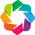

In [3]:
from ta_lib.core.api import (
    create_context,
    get_dataframe,
    load_dataset,
    initialize_environment,
    DEFAULT_ARTIFACTS_PATH,
)
from ta_lib.regression.api import RegressionComparison, RegressionReport

from taregression.elastic_net_api import ElasticNet
from taregression.linear_mixed_effects_api import LinearMixedEffects

initialize_environment(debug=False, hide_warnings=True)

config_path = op.join("conf", "config.yml")
context = create_context(config_path)

artifacts_folder = DEFAULT_ARTIFACTS_PATH


## 2. Load the Housing Training and Test Data


In [4]:
train_X = load_dataset(context, "train/housing/features")
train_y = load_dataset(context, "train/housing/target")
test_X = load_dataset(context, "test/housing/features")
test_y = load_dataset(context, "test/housing/target")

train_df = train_X.copy()
train_df["median_house_value"] = train_y["median_house_value"].values

test_df = test_X.copy()
test_df["median_house_value"] = test_y["median_house_value"].values

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())


Training shape: (16512, 13)
Test shape: (4128, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
0,-118.04,33.99,47.0,2530.0,565.0,1262.0,509.0,3.6475,1H OCEAN,4.970530,0.223320,2.479371,197100.0
1,-122.20,37.82,37.0,1229.0,181.0,420.0,176.0,7.0175,NEAR BAY,6.982955,0.147274,2.386364,366700.0
2,-118.25,34.09,52.0,3142.0,765.0,1728.0,682.0,3.1864,1H OCEAN,4.607038,0.243475,2.533724,189800.0
3,-117.99,33.70,25.0,2017.0,357.0,1063.0,369.0,4.0345,1H OCEAN,5.466125,0.176996,2.880759,229400.0
4,-120.88,37.52,2.0,1871.0,409.0,707.0,256.0,2.6103,INLAND,7.308594,0.218600,2.761719,133600.0


### Target and feature overview

The target is `median_house_value`.

`ocean_proximity` is retained as a categorical feature and also provides a natural grouping factor for the Linear Mixed Effects example.


In [5]:
print("Target:", "median_house_value")
print("\nCategorical columns:")
print(train_X.select_dtypes(include=["object", "string", "category"]).columns.tolist())

print("\nNumeric columns:")
print(train_X.select_dtypes(include=["number"]).columns.tolist())


Target: median_house_value

Categorical columns:
['ocean_proximity']

Numeric columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


In [6]:
# TA-Regression does not perform sklearn-style imputation.
# Fill missing values using training-set statistics.
train_df = train_df.copy()
test_df = test_df.copy()

bedrooms_median = train_df["total_bedrooms"].median()

train_df["total_bedrooms"] = train_df["total_bedrooms"].fillna(
    bedrooms_median
)
test_df["total_bedrooms"] = test_df["total_bedrooms"].fillna(
    bedrooms_median
)

train_df["bedrooms_per_room"] = (
    train_df["total_bedrooms"] / train_df["total_rooms"]
)
test_df["bedrooms_per_room"] = (
    test_df["total_bedrooms"] / test_df["total_rooms"]
)

## 3. TA-Regression ElasticNet

ElasticNet provides a regularized linear model and is useful here as an interpretable baseline.

The TA-Regression API accepts a Wilkinson-style model formula. Categorical `ocean_proximity` levels are represented using `C(ocean_proximity)`.


In [7]:
numeric_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
]

elastic_formula = (
    "median_house_value ~ "
    + " + ".join(numeric_features)
    + " + C(ocean_proximity)"
)

print(elastic_formula)


median_house_value ~ longitude + latitude + housing_median_age + total_rooms + total_bedrooms + population + households + median_income + rooms_per_household + bedrooms_per_room + population_per_household + C(ocean_proximity)


In [8]:
elastic_model = ElasticNet(
    elastic_formula,
    backend="sklearn",
)

elastic_model.fit(
    train_df,
    alpha=0.5,
    lmbd=0.003,
    max_iter=10000,
)

elastic_coefficients = elastic_model.get_coefficients()
elastic_coefficients


/mnt/c/capstone_project_house_price_prediction/ta-lib-tareg-dev/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.001e+13, tolerance: 9.270e+10
  model = cd_fast.enet_coordinate_descent(


{'Intercept': -45301.86676230211,
 'longitude': -952.920147776919,
 'latitude': -1814.6528442731317,
 'housing_median_age': 1114.119744481389,
 'total_rooms': -4.254828612723448,
 'total_bedrooms': 34.15063227610617,
 'population': -37.3637931256087,
 'households': 110.55944514945809,
 'median_income': 40208.39471379694,
 'rooms_per_household': 1341.9150297032747,
 'bedrooms_per_room': 76791.90409282225,
 'population_per_household': 53.49649425071183,
 'C(ocean_proximity)': -64348.53296871913}

### ElasticNet predictions and report


In [9]:
elastic_train_pred = np.asarray(elastic_model.predict(train_df)).reshape(-1)
elastic_test_pred = np.asarray(elastic_model.predict(test_df)).reshape(-1)

elastic_report = RegressionReport(
    x_train=train_X,
    y_train=train_y,
    x_test=test_X,
    y_test=test_y,
    yhat_train=elastic_train_pred,
    yhat_test=elastic_test_pred,
)

elastic_report.get_report(
    include_shap=False,
    file_path="reports/ta_reg_elastic_net_report",
)


In [10]:
rf_pipeline = joblib.load("../../artifacts/housing_final_model.joblib")
rf_test_pred = np.asarray(
    rf_pipeline.predict(test_X)
).reshape(-1)

elastic_comparison = RegressionComparison(
    y=test_y["median_house_value"],
    yhats={
        "TA-Regression ElasticNet": elastic_test_pred,
        "Random Forest": rf_test_pred,
    },
)

elastic_metrics = elastic_comparison.perf_metrics()
display(elastic_metrics)

### ElasticNet coefficient visualization

The coefficients provide an interpretable view of how the housing variables contribute to predicted house value.


In [11]:
if isinstance(elastic_coefficients, dict):
    coefficient_items = elastic_coefficients.items()
    coefficient_df = pd.DataFrame(
        coefficient_items,
        columns=["feature", "coefficient"],
    )
else:
    coefficient_df = pd.DataFrame(elastic_coefficients)

if {"feature", "coefficient"}.issubset(coefficient_df.columns):
    coefficient_plot = (
        coefficient_df.assign(abs_coefficient=lambda x: x["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
        .head(15)
        .sort_values("coefficient")
    )

    coefficient_plot.plot(
        x="feature",
        y="coefficient",
        kind="barh",
        figsize=(10, 6),
        legend=False,
        title="Top ElasticNet Coefficients",
    )
    plt.tight_layout()
    plt.show()
else:
    display(coefficient_df.head(20))


/mnt/c/capstone_project_house_price_prediction/ta-lib-tareg-dev/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/mnt/c/capstone_project_house_price_prediction/ta-lib-tareg-dev/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/tmp/ipykernel_258634/2852441359.py:27: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


## 4. TA-Regression Linear Mixed Effects

Housing observations can be grouped by `ocean_proximity`.

A mixed-effects model allows the relationship between `median_income` and house value to vary by the `ocean_proximity` group while retaining common fixed effects.

Because mixed-effects models are substantially more expensive than the Random Forest benchmark, the experiment uses a reproducible subset of the training data.


In [12]:
lme_columns = [
    "median_house_value",
    "longitude",
    "latitude",
    "housing_median_age",
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "ocean_proximity",
]

lme_train = train_df[lme_columns].dropna().copy()
lme_test = test_df[lme_columns].dropna().copy()

lme_sample = lme_train.sample(
    n=min(6000, len(lme_train)),
    random_state=context.random_seed,
)

print("LME training rows:", len(lme_sample))
print("LME test rows:", len(lme_test))


LME training rows: 6000
LME test rows: 4128


In [13]:
lme_formula = (
    "median_house_value ~ "
    "longitude + latitude + housing_median_age + median_income + "
    "rooms_per_household + bedrooms_per_room + population_per_household + "
    "(median_income|ocean_proximity)"
)

print(lme_formula)


median_house_value ~ longitude + latitude + housing_median_age + median_income + rooms_per_household + bedrooms_per_room + population_per_household + (median_income|ocean_proximity)


In [14]:
lme_model = LinearMixedEffects(
    lme_formula,
    backend="statsmodels",
)

lme_model.fit(
    lme_sample,
    verbose=True,
)


Fixed Effects Coefficients
+--------------------------+---------------+
| Term                     |         Coeff |
|--------------------------+---------------|
| Intercept                | -2557697.1825 |
| longitude                |   -29224.7983 |
| latitude                 |   -27249.6600 |
| housing_median_age       |      879.5069 |
| median_income            |    47206.1915 |
| rooms_per_household      |     3117.8153 |
| bedrooms_per_room        |   218244.5179 |
| population_per_household |     -302.5194 |
+--------------------------+---------------+
Random Effects Coefficients
+-------------------------------+---------+----------------+------------+-------------+------------+
| Term                          |    Mean |            Var |        Std |         Min |        Max |
|-------------------------------+---------+----------------+------------+-------------+------------|
| 1|ocean_proximity             | -0.0000 |  62736697.6030 |  7920.6501 | -14964.9542 |  8040.1517 |
|

/mnt/c/capstone_project_house_price_prediction/ta-lib-tareg-dev/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


LinearMixedEffects(formula='median_house_value ~ longitude + latitude + '
                           'housing_median_age + median_income + '
                           'rooms_per_household + bedrooms_per_room + '
                           'population_per_household + '
                           '(median_income|ocean_proximity)')

In [15]:
lme_coefficients = lme_model.get_coefficients()

fixed_effects = pd.DataFrame(
    lme_coefficients["common"].items(),
    columns=["feature", "coefficient"],
)

display(fixed_effects)


,feature,coefficient
0,Intercept,-2.557697e+06
1,longitude,-2.922480e+04
2,latitude,-2.724966e+04
3,housing_median_age,8.795069e+02
4,median_income,4.720619e+04
5,rooms_per_household,3.117815e+03
6,bedrooms_per_room,2.182445e+05
7,population_per_household,-3.025194e+02


In [16]:
lme_train_pred = np.asarray(lme_model.predict(lme_sample)).reshape(-1)
lme_test_pred = np.asarray(lme_model.predict(lme_test)).reshape(-1)

lme_report = RegressionReport(
    x_train=lme_sample.drop(columns=["median_house_value"]),
    y_train=lme_sample[["median_house_value"]],
    x_test=lme_test.drop(columns=["median_house_value"]),
    y_test=lme_test[["median_house_value"]],
    yhat_train=lme_train_pred,
    yhat_test=lme_test_pred,
)

lme_report.get_report(
    include_shap=False,
    file_path="reports/ta_reg_lme_report",
)


## 5. Model Comparison

The tuned Random Forest from Notebook 03 is used as the predictive benchmark.

The benchmark was:

- Random Forest
- `max_depth=20`
- `max_features=0.5`
- `min_samples_leaf=2`
- `n_estimators=215`
- `random_state=0`

Its Notebook 03 test performance was approximately:

- MAE: 31,727
- RMSE: 47,863
- R²: 0.827


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_test_path = op.join(
    artifacts_folder,
    "housing_final_model.joblib",
)

try:
    import joblib

    rf_model = joblib.load(rf_test_path)

    rf_test_pred = rf_model.predict(test_X)

    benchmark_metrics = {
        "Model": "Tuned Random Forest",
        "MAE": mean_absolute_error(test_y["median_house_value"], rf_test_pred),
        "RMSE": mean_squared_error(
            test_y["median_house_value"],
            rf_test_pred,
        ),
        "R2": r2_score(test_y["median_house_value"], rf_test_pred),
    }

    display(pd.DataFrame([benchmark_metrics]))

except FileNotFoundError:
    print(
        "Notebook 03 Random Forest artifact was not found at:",
        rf_test_path,
    )


,Model,MAE,RMSE,R2
0,Tuned Random Forest,20247.456151,1.070752e+09,0.919514


In [18]:
comparison_rows = [
    {
        "Model": "TA-Regression ElasticNet",
        "MAE": mean_absolute_error(
            test_y["median_house_value"],
            elastic_test_pred,
        ),
        "RMSE": mean_squared_error(
            test_y["median_house_value"],
            elastic_test_pred,
        ),
        "R2": r2_score(
            test_y["median_house_value"],
            elastic_test_pred,
        ),
    },
    {
        "Model": "TA-Regression LinearMixedEffects",
        "MAE": mean_absolute_error(
            lme_test["median_house_value"],
            lme_test_pred,
        ),
        "RMSE": mean_squared_error(
            lme_test["median_house_value"],
            lme_test_pred,
        ),
        "R2": r2_score(
            lme_test["median_house_value"],
            lme_test_pred,
        ),
    },
]

if "benchmark_metrics" in globals():
    comparison_rows.append(benchmark_metrics)

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE")
display(comparison_df)


,Model,MAE,RMSE,R2
2,Tuned Random Forest,20247.456151,1.070752e+09,0.919514
0,TA-Regression ElasticNet,50366.135404,4.873741e+09,0.633651
1,TA-Regression LinearMixedEffects,52266.356904,5.204478e+09,0.608790


In [19]:
comparison_plot = comparison_df.set_index("Model")[["RMSE"]]
comparison_plot.plot(
    kind="bar",
    figsize=(9, 5),
    title="Housing Model RMSE Comparison",
    ylabel="RMSE",
    legend=False,
)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


/tmp/ipykernel_258634/3950732859.py:11: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


## 6. Conclusions

The TA-Regression experiments demonstrate two useful modelling approaches for the housing problem:

1. **ElasticNet** provides a regularized and interpretable linear baseline.
2. **Linear Mixed Effects** demonstrates how grouped housing characteristics can be modelled with group-specific effects.

The tuned Random Forest from Notebook 03 remains the primary predictive model because it provides the strongest predictive performance on this dataset.

TA-Regression is therefore complementary to the final production model: it provides interpretable regression and mixed-effects experimentation, while the Random Forest is retained for production scoring.


## 7. Reproducibility

All experiments use the project configuration and `context.random_seed`.

The notebook consumes the datasets generated by Notebook 02 and does not independently recreate the production feature-engineering pipeline.

Generated reports are stored under:

`notebooks/reference/reports/`
